<h2>Data Import</h2>

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

demo = pd.read_sas('/Users/rupeshphyaulimagar/Data/NHANES data/DEMO_L.xpt')
bmx = pd.read_sas('/Users/rupeshphyaulimagar/Data/NHANES data/BMX_L.xpt')
paq = pd.read_sas('/Users/rupeshphyaulimagar/Data/NHANES data/PAQ_L.xpt')

<br>

<h2>EDA</h2>

<br>
<h3>From demo dataset we fetch Age and Gender

In [9]:
demo.head(2)

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.0
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.0


In [10]:
demo = demo[['SEQN','RIAGENDR','RIDAGEYR']]
demo.columns=['SEQN','Sex','Age']

In [11]:
demo['Sex'] = demo['Sex'].replace({
    1: 1,   
    2: 0    
})

In [12]:
demo.head(2)

,SEQN,Sex,Age
0,130378.0,1.0,43.0
1,130379.0,1.0,66.0


In [13]:
demo['Sex'].unique()

array([1., 0.])

In [14]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEQN    11933 non-null  float64
 1   Sex     11933 non-null  float64
 2   Age     11933 non-null  float64
dtypes: float64(3)
memory usage: 279.8 KB


<br>
<h3>    From bmx dataset we fetch Weight, Height and BMI

In [15]:
bmx.head()

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,130378.0,1.0,86.9,NaN,NaN,NaN,NaN,NaN,179.5,NaN,...,42.8,NaN,42.0,NaN,35.7,NaN,98.3,NaN,102.9,NaN
1,130379.0,1.0,101.8,NaN,NaN,NaN,NaN,NaN,174.2,NaN,...,38.5,NaN,38.7,NaN,33.7,NaN,114.7,NaN,112.4,NaN
2,130380.0,1.0,69.4,NaN,NaN,NaN,NaN,NaN,152.9,NaN,...,38.5,NaN,35.5,NaN,36.3,NaN,93.5,NaN,98.0,NaN
3,130381.0,1.0,34.3,NaN,NaN,NaN,NaN,NaN,120.1,NaN,...,NaN,NaN,25.4,NaN,23.4,NaN,70.4,NaN,NaN,NaN
4,130382.0,3.0,13.6,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN


In [16]:
print(bmx.columns.tolist())

['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']


In [17]:
bmx = bmx[['SEQN','BMXWT','BMXHT','BMXBMI']].rename(columns={'BMXWT':'weight(kg)','BMXHT':'Height(cm)','BMXBMI':'BMI'})

In [18]:
bmx.head(2)

,SEQN,weight(kg),Height(cm),BMI
0,130378.0,86.9,179.5,27.0
1,130379.0,101.8,174.2,33.5


In [19]:
bmx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8860 entries, 0 to 8859
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SEQN        8860 non-null   float64
 1   weight(kg)  8754 non-null   float64
 2   Height(cm)  8499 non-null   float64
 3   BMI         8471 non-null   float64
dtypes: float64(4)
memory usage: 277.0 KB


<br>
<h3>    From paq dataset we fetch PAD680 which have activity in miniute

In [20]:
paq.head()

,SEQN,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680
0,130378.0,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0
1,130379.0,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0
2,130380.0,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0
3,130384.0,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,60.0
4,130385.0,1.000000e+00,b'D',90.0,1.000000e+00,b'W',60.0,180.0


In [21]:
paq = paq[['SEQN','PAD680']]

def activity_level(minutes):

    if minutes < 240:
        return '0'

    elif minutes <= 480:
        return '1'

    else:
        return '2'

paq['Activity_Level'] = paq['PAD680'].apply(activity_level)

paq = paq[['SEQN','Activity_Level']]


In [22]:
paq.head(2)

,SEQN,Activity_Level
0,130378.0,1
1,130379.0,1


In [23]:
paq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8153 entries, 0 to 8152
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SEQN            8153 non-null   float64
 1   Activity_Level  8153 non-null   object 
dtypes: float64(1), object(1)
memory usage: 127.5+ KB


<h3>Merging 3 dataset</h3>

In [24]:
df = demo.merge(bmx,on='SEQN').merge(paq, on='SEQN')

In [25]:
df.shape

(6337, 7)

In [26]:
df.head()

,SEQN,Sex,Age,weight(kg),Height(cm),BMI,Activity_Level
0,130378.0,1.0,43.0,86.9,179.5,27.0,1
1,130379.0,1.0,66.0,101.8,174.2,33.5,1
2,130380.0,0.0,44.0,69.4,152.9,29.7,1
3,130386.0,1.0,34.0,90.6,173.3,30.2,0
4,130387.0,0.0,68.0,103.5,155.9,42.6,2


In [27]:
df.isnull().sum()

SEQN                0
Sex                 0
Age                 0
weight(kg)         89
Height(cm)         75
BMI               102
Activity_Level      0
dtype: int64

In [28]:
df = df.dropna(subset=['weight(kg)', 'Height(cm)', 'BMI'])

In [29]:
df.shape

(6235, 7)

<br><h2>Calculating Fat in percentage using Deurenberg Formula</h2>

In [30]:
df['Fat_%'] = (1.2 * df['BMI']) + (0.23 * df['Age']) - (10.8 * df['Sex']) - 5.4

In [31]:
df= df.drop(columns="SEQN")

In [32]:
df.head()

,Sex,Age,weight(kg),Height(cm),BMI,Activity_Level,Fat_%
0,1.0,43.0,86.9,179.5,27.0,1,26.09
1,1.0,66.0,101.8,174.2,33.5,1,39.18
2,0.0,44.0,69.4,152.9,29.7,1,40.36
3,1.0,34.0,90.6,173.3,30.2,0,27.86
4,0.0,68.0,103.5,155.9,42.6,2,61.36


<br> 
<h2>Visualisation</h2>

<h2>Histogram</h2>

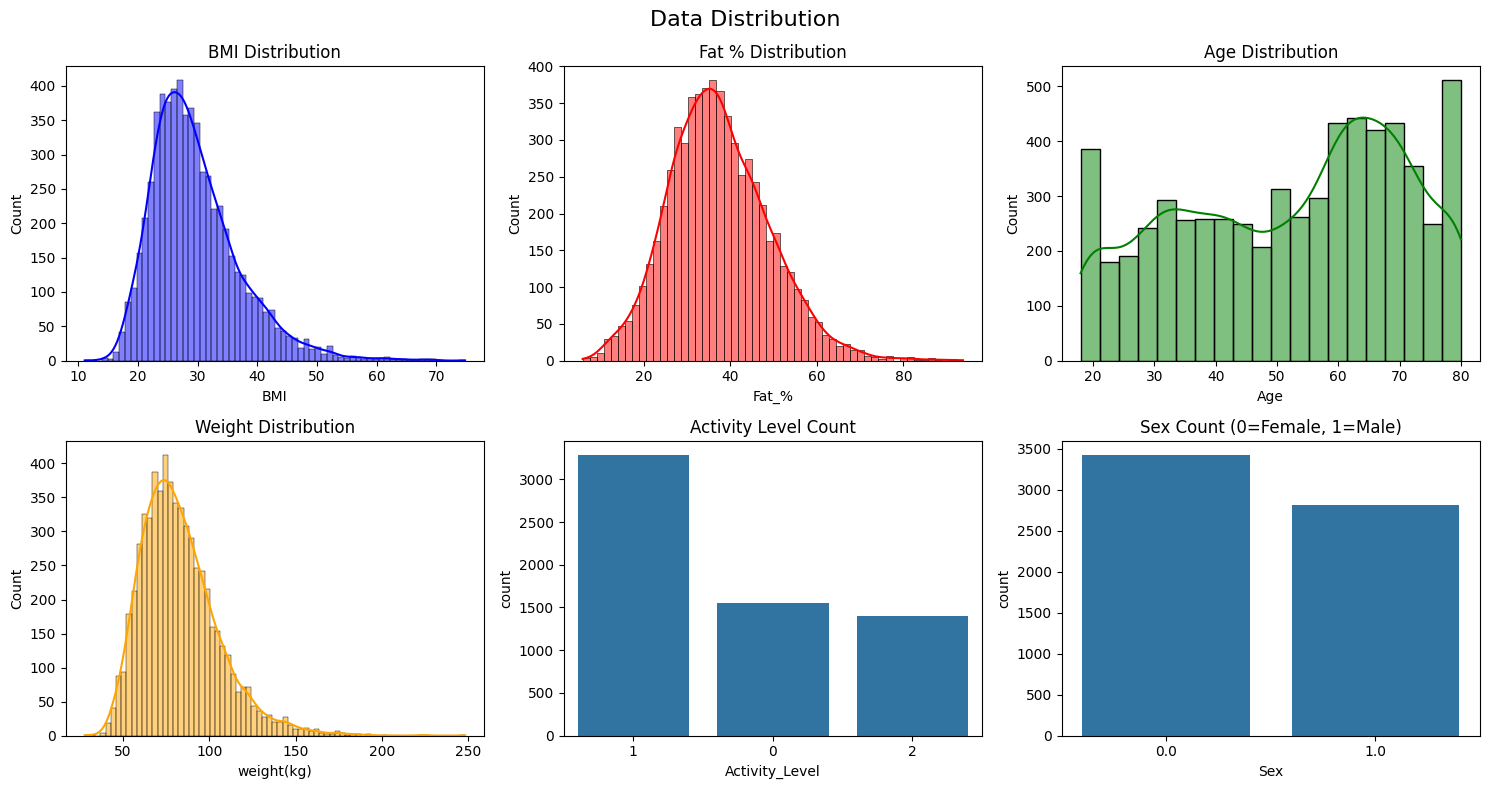

In [33]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Data Distribution', fontsize=16)

sns.histplot(df['BMI'], ax=axes[0,0], kde=True, color='blue')
axes[0,0].set_title('BMI Distribution')

sns.histplot(df['Fat_%'], ax=axes[0,1], kde=True, color='red')
axes[0,1].set_title('Fat % Distribution')

sns.histplot(df['Age'], ax=axes[0,2], kde=True, color='green')
axes[0,2].set_title('Age Distribution')

sns.histplot(df['weight(kg)'], ax=axes[1,0], kde=True, color='orange')
axes[1,0].set_title('Weight Distribution')

sns.countplot(x='Activity_Level', data=df, ax=axes[1,1])
axes[1,1].set_title('Activity Level Count')

sns.countplot(x='Sex', data=df, ax=axes[1,2])
axes[1,2].set_title('Sex Count (0=Female, 1=Male)')

plt.tight_layout()
plt.show()

<h2>Heatmap</h2>

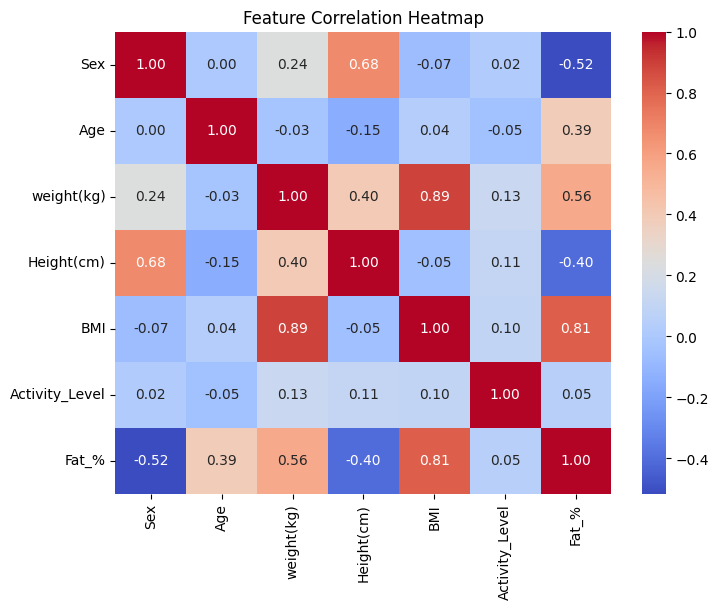

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

<h2></h2>

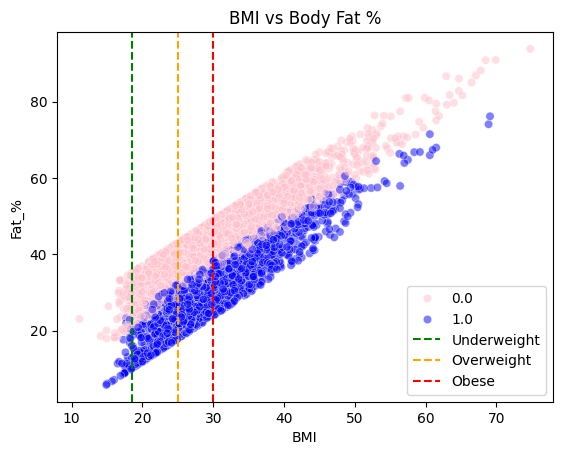

In [34]:
sns.scatterplot(data=df, x='BMI', y='Fat_%', hue='Sex', 
                palette={0:'pink', 1:'blue'}, alpha=0.5)
plt.title('BMI vs Body Fat %')
plt.axvline(18.5, color='green', linestyle='--', label='Underweight')
plt.axvline(25, color='orange', linestyle='--', label='Overweight')
plt.axvline(30, color='red', linestyle='--', label='Obese')
plt.legend()
plt.show()

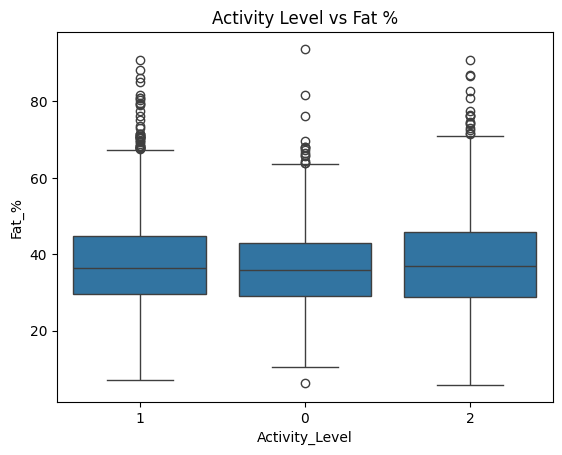

In [40]:
sns.boxplot(data=df, x='Activity_Level', y='Fat_%')
plt.title('Activity Level vs Fat %')
plt.show()